In [288]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [289]:
pd.set_option('display.max_columns', None)

In [290]:
df = pd.read_csv(r'C:\Users\ACER\Desktop\Projects\Machine Learning Based Real Estate System\Dataset\Cleaned_Properties_V2.csv').drop_duplicates()
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,umang winter hills,sector 77,1.00,7500.0,1333.0,Carpet area: 1340 (124.49 sq.m.),2,2,2,3.0,NaN,New Property,NaN,NaN,1340.0,0,0,0,0,0,1,74
1,flat,emaar mgf emerald estate,sector 65,1.75,12544.0,1395.0,Super Built up area 1395(129.6 sq.m.)Carpet ar...,3,3,3,10.0,North-East,Relatively New,1395.0,NaN,809.0,0,1,0,0,0,0,124
2,house,suncity township,sector 54,2.00,30968.0,646.0,Plot area 60Built Up area: 60 sq.m.Carpet area...,9,9,3,11.0,North,Relatively New,NaN,60.0,59.0,0,1,0,0,0,2,7
3,house,independent,sector 108,1.70,5666.0,3000.0,Built Up area: 3000 (278.71 sq.m.)Carpet area:...,4,4,3+,1.0,North-East,Undefined,NaN,3000.0,2600.0,0,0,0,0,0,1,0
4,flat,dlf the ultima,sector 81,2.30,10994.0,2092.0,Super Built up area 2092(194.35 sq.m.),3,4,3+,6.0,East,New Property,2092.0,NaN,NaN,0,1,0,0,0,2,167


In [291]:
df.shape

(3728, 23)

In [292]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

### price

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\3343439101.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


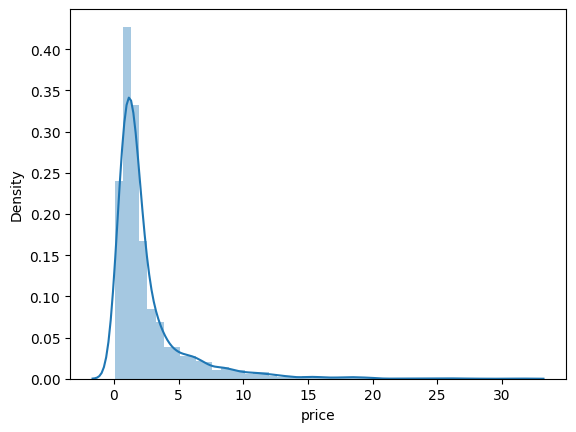

In [293]:
# Outliers on the Basis of Price Column
sns.distplot(df['price'])
plt.show()

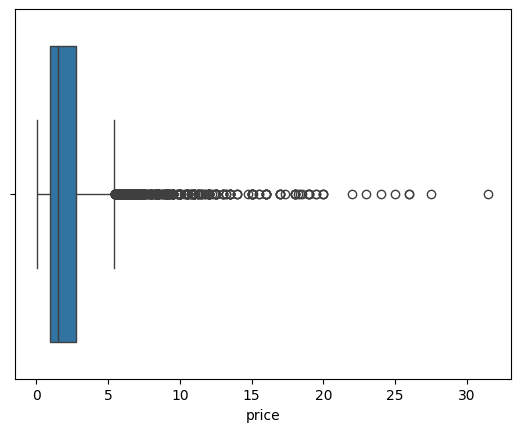

In [294]:
sns.boxplot(x=df['price'])
plt.show()

In [295]:
# Calculate the IQR for the 'price' Column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify Outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(431,
 count    431.000000
 mean       9.214478
 std        4.064876
 min        5.460000
 25%        6.420000
 50%        8.000000
 75%       10.655000
 max       31.500000
 Name: price, dtype: float64)

In [296]:
outliers.sort_values('price', ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
92,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately New,NaN,9000.0,NaN,1,1,1,1,0,2,74
3831,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,0,42
2336,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,2,72
3678,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,0,138
2431,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately New,NaN,1000.0,NaN,1,1,1,1,0,1,0
3076,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,0,122
841,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,NaN,9000.0,NaN,1,1,1,1,0,0,145
3516,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,Moderately New,NaN,1000.0,NaN,0,1,0,0,0,1,54
3304,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,2,97
836,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,0,31


On the basis of Price column we can state that there are some genuine outliers but there are some data error as well

### price_per_sqft

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\575062949.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


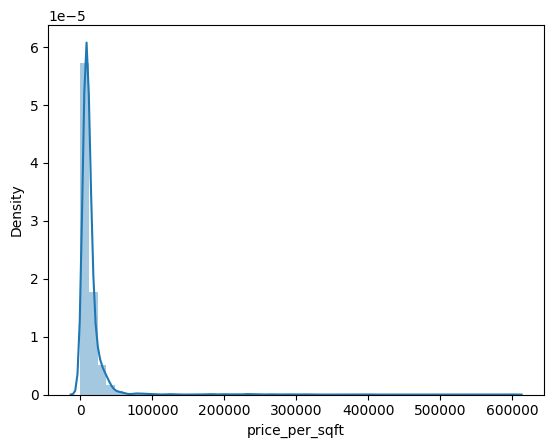

In [297]:
sns.distplot(df['price_per_sqft'])
plt.show()

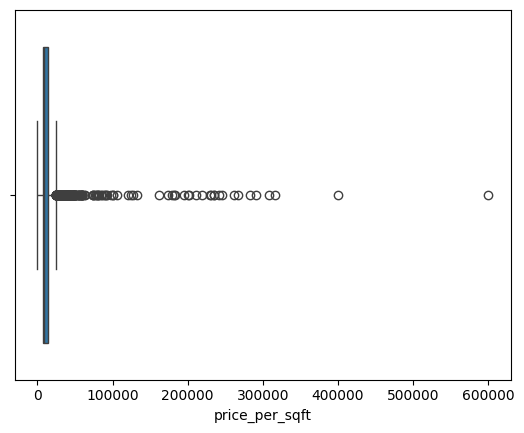

In [298]:
sns.boxplot(x=df['price_per_sqft'])
plt.show()

In [299]:
# Calculate the IQR for the 'price_per_sqft' Column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify Outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers_sqft and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(358,
 count       358.000000
 mean      52644.340782
 std       60826.009563
 min       24489.000000
 25%       28241.250000
 50%       33628.500000
 75%       42159.000000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [300]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [301]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [302]:
outliers_sqft['price_per_sqft'].describe()

count      358.000000
mean     29189.209497
std      12503.452307
min       2723.000000
25%      25546.250000
50%      29788.500000
75%      35549.500000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [303]:
df.update(outliers_sqft)

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\575062949.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


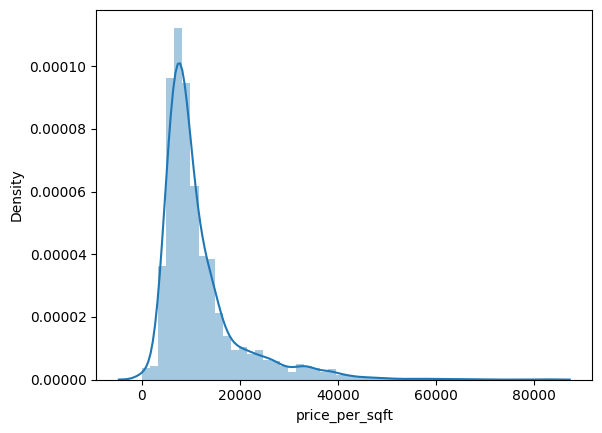

In [304]:
sns.distplot(df['price_per_sqft'])
plt.show()

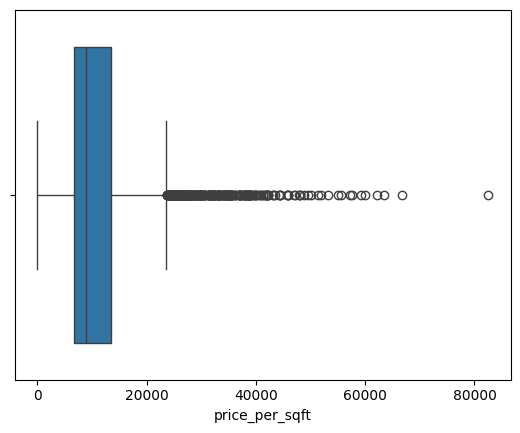

In [305]:
sns.boxplot(x=df['price_per_sqft'])
plt.show()

In [306]:
df[df['price_per_sqft'] > 50000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
104,house,malibu towne,sector 47,8.50,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,New Property,NaN,1600.0,NaN,0,0,0,0,0,0,99
467,house,emaar mgf marbella,sector 66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately New,NaN,3240.0,NaN,1,1,0,1,0,2,75
871,house,nul,sector 28,12.50,51440.0,2430.0,Plot area 270(225.75 sq.m.),16,17,3+,4.0,South,Relatively New,NaN,2430.0,NaN,1,1,0,1,1,2,137
885,house,project housing board colony,sector 31,8.00,63492.0,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,1.0,NaN,Undefined,NaN,140.0,NaN,0,0,0,0,0,1,0
1921,house,unitech escape,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,2.0,North,Relatively New,NaN,250.0,200.0,1,1,1,1,0,0,103
2336,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,2,72
2622,house,independent,sector 25,16.00,59259.0,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,4.0,West,New Property,NaN,325.0,300.0,1,1,1,1,0,2,72
2753,flat,unitech vistas,sector 70,9.00,57508.0,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,0,7.0,NaN,Undefined,NaN,1565.0,NaN,0,0,0,0,0,1,0
3076,house,emaar the palm springs,sector 54,24.00,66667.0,3600.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,0,122
3091,house,cloudnine cottages,sohna road road,5.50,55000.0,1000.0,Plot area 1000(92.9 sq.m.),3,3,0,1.0,NaN,Moderately New,NaN,1000.0,NaN,0,0,0,0,0,1,0


In [307]:
df = df[df['price_per_sqft'] <= 50000]

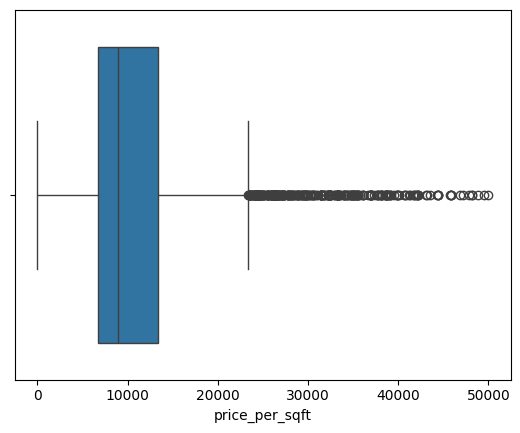

In [308]:
sns.boxplot(x=df['price_per_sqft'])
plt.show()

### area

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\2660226674.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


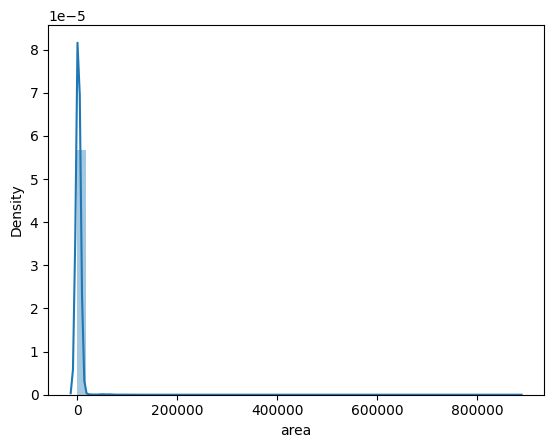

In [309]:
sns.distplot(df['area'])
plt.show()

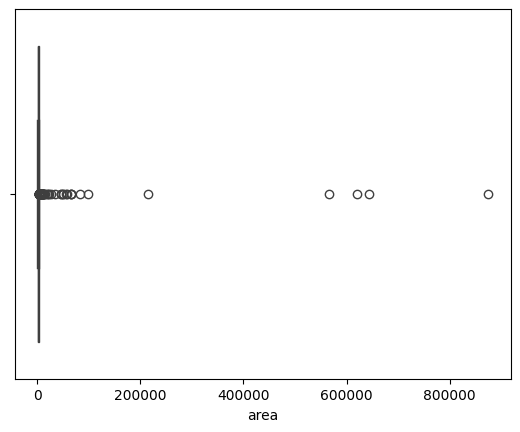

In [310]:
sns.boxplot(x=df['area'])
plt.show()

In [311]:
df['area'].describe()

count      3698.000000
mean       2951.555435
std       23064.729602
min         145.000000
25%        1260.250000
50%        1750.000000
75%        2350.000000
max      875000.000000
Name: area, dtype: float64

In [312]:
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1941,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,1,76
1989,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,2.0,NaN,1,1,0,1,1,0,0
2841,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,NaN,NaN,607936.0,1,0,0,0,1,1,65
3045,flat,hcbs sports ville,sohna road road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,2,44
3415,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,1,44


In [313]:
df = df[df['area'] < 100000]

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\2660226674.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


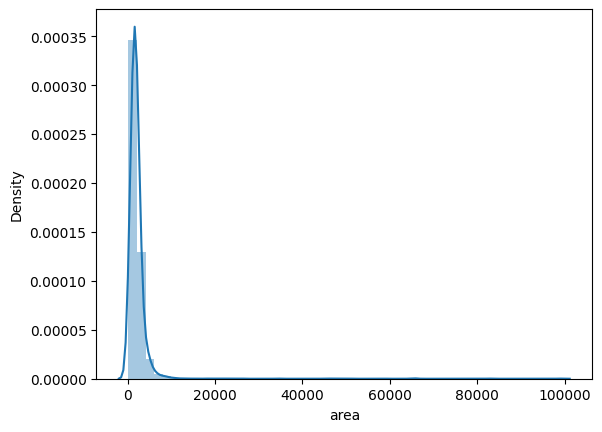

In [314]:
sns.distplot(df['area'])
plt.show()

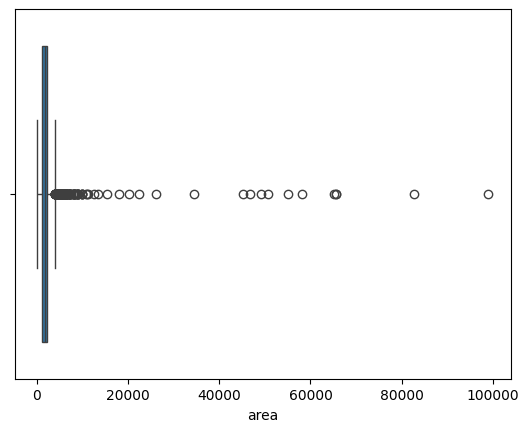

In [315]:
sns.boxplot(x=df['area'])
plt.show()

In [316]:
df[df['area'] > 10000].sort_values('area', ascending=False)

# 2218, 241, 3809, 3203, 1537, 1339, 377, 341, 3707

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2808,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,0,60
2256,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,1,7
241,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,1,15
3809,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,1,51
385,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,1,0
3203,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,1,15
1537,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,1,37
3345,house,independent,sector 51,5.50,1087.0,50598.0,Plot area 5620(4699.04 sq.m.)Built Up area: 82...,8,8,2,3.0,North-East,Relatively New,NaN,8260.0,4860.00,0,0,0,1,0,0,49
1339,flat,signature the serenas,sohna road road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,1,37
1408,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,0,109


In [317]:
df.drop(index=[2218, 241, 3809, 3203, 1537, 1339, 377, 341, 3707], inplace=True)

In [318]:
pd.set_option('display.max_colwidth', None)
df[df['area'] > 10000].sort_values('area', ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2808,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 sq.yards (9197.4 sq.m.),6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,0,60
2256,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,1,7
385,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,1,0
3345,house,independent,sector 51,5.50,1087.0,50598.0,Plot area 5620(4699.04 sq.m.)Built Up area: 8260 sq.yards (6906.41 sq.m.)Carpet area: 4860 sq.yards (4063.58 sq.m.),8,8,2,3.0,North-East,Relatively New,NaN,8260.0,4860.00,0,0,0,1,0,0,49
1408,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800 sq.yards (4849.54 sq.m.)Carpet area: 5200 sq.yards (4347.86 sq.m.),9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,0,109
2177,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 2660 sq.yards (2224.1 sq.m.)Carpet area: 2500 sq.yards (2090.32 sq.m.),9,9,3+,3.0,North-East,New Property,NaN,2660.0,2500.00,0,1,0,0,0,0,61
2007,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850 sq.yards (2382.96 sq.m.)Carpet area: 2250 sq.yards (1881.29 sq.m.),8,7,3+,3.0,East,Moderately New,NaN,2850.0,2250.00,1,1,0,1,1,0,123
491,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Relatively New,NaN,NaN,18122.00,1,0,0,1,1,0,44
1145,house,unitech aspen greens,sector 50,6.95,4490.0,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160 sq.yards (1806.04 sq.m.)Carpet area: 1720 sq.yards (1438.14 sq.m.),3,3,1,2.0,North-East,Moderately New,NaN,2160.0,1720.00,0,1,0,0,0,1,160
3162,house,independent,sector 4,0.85,630.0,13492.0,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,Relatively New,NaN,13500.0,NaN,0,0,0,0,1,1,0


In [319]:
df.loc[2808, 'area'] = 11000
df.loc[2256, 'area'] = 115*9
df.loc[385, 'area'] = 7250
df.loc[3345, 'area'] = 8260
df.loc[1408, 'area'] = 5800
df.loc[2177, 'area'] = 2660 
df.loc[2007, 'area'] = 2850 
df.loc[491, 'area'] = 1812
df.loc[1145, 'area'] = 2160 
df.loc[3162, 'area'] = 1500
df.loc[451, 'area'] = 1175
df.loc[3831, 'area'] = 1254
df.loc[336, 'area'] = 1100
df.loc[1697, 'area'] = 3500 

In [320]:
pd.reset_option('display.max_colwidth')

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\2660226674.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


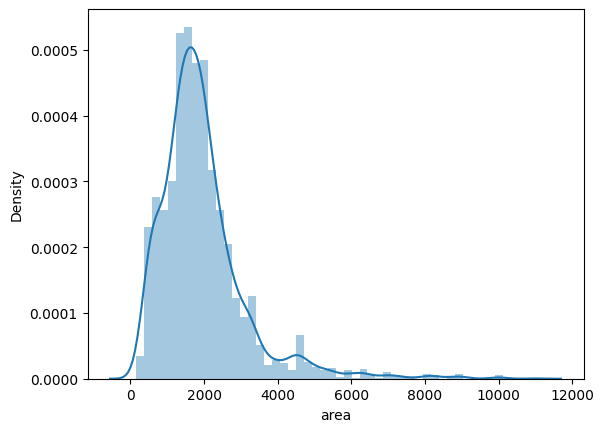

In [321]:
sns.distplot(df['area'])
plt.show()

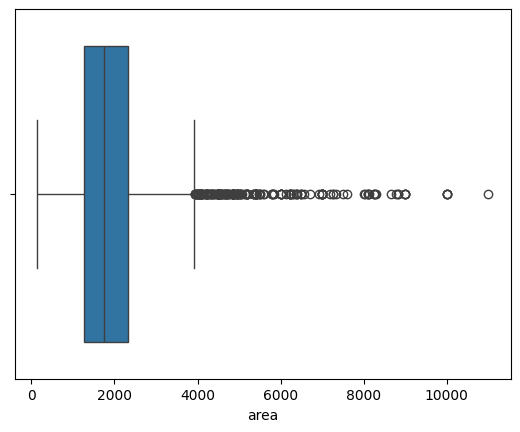

In [322]:
sns.boxplot(x=df['area'])
plt.show()

In [323]:
df['area'].describe()

count     3684.000000
mean      1945.276873
std       1200.035674
min        145.000000
25%       1258.750000
50%       1745.000000
75%       2326.000000
max      11000.000000
Name: area, dtype: float64

### bedroom

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\592609350.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


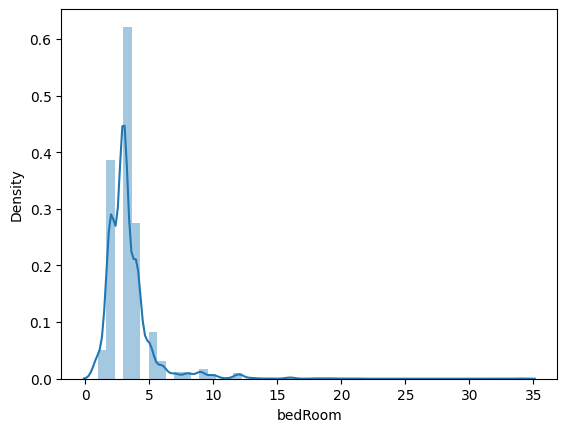

In [324]:
sns.distplot(df['bedRoom'])
plt.show()

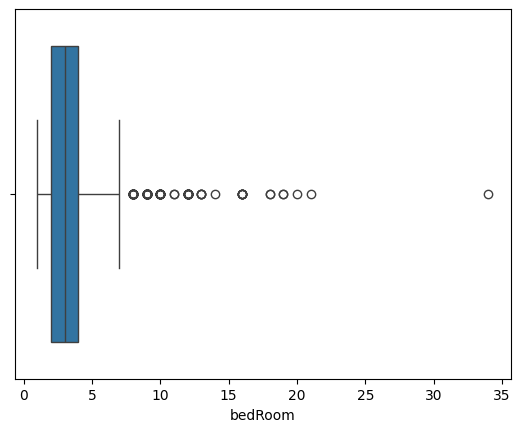

In [325]:
sns.boxplot(x=df['bedRoom'])
plt.show()

In [326]:
df['bedRoom'].describe()

count    3684.000000
mean        3.347720
std         1.900853
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        34.000000
Name: bedRoom, dtype: float64

In [327]:
df[df['bedRoom'] > 10].sort_values('bedRoom', ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2280,house,manohar nagar,sector 5,5.60,12444.0,4500.0,Plot area 500(418.06 sq.m.)Built Up area: 500 ...,34,34,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,0,0,0,0,0,0
59,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,2,49
1111,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,NaN,1152.0,NaN,0,1,0,0,0,2,22
1810,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,1,68
1258,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,NaN,1622.0,NaN,1,1,1,1,0,1,74
791,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,NaN,1503.0,NaN,0,0,0,0,1,2,57
877,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0,1,0,0,0,2,70
3135,house,dlf city plots,sector 26,20.00,44267.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.0,NaN,1,1,1,1,0,0,153
1465,house,independent,sector 43,13.50,50000.0,2700.0,Plot area 300(250.84 sq.m.),16,16,3+,4.0,North-West,Relatively New,NaN,2700.0,NaN,1,1,0,1,1,1,41
1997,house,independent,sector 4,4.50,25000.0,1800.0,Plot area 200(167.23 sq.m.),16,16,3+,4.0,South,Relatively New,NaN,1800.0,NaN,0,0,0,0,0,0,20


In [328]:
df = df[df['bedRoom'] <= 10]

In [329]:
df.shape

(3637, 23)

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\592609350.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


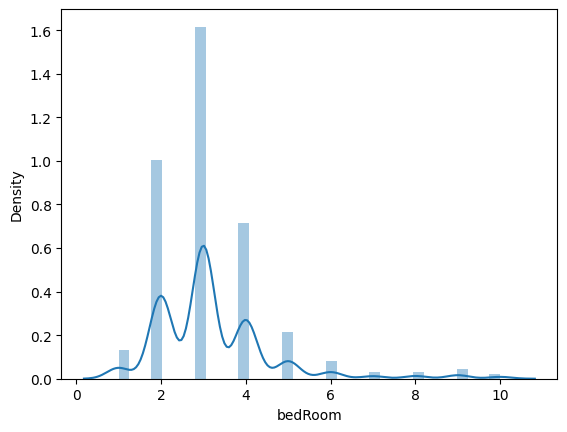

In [330]:
sns.distplot(df['bedRoom'])
plt.show()

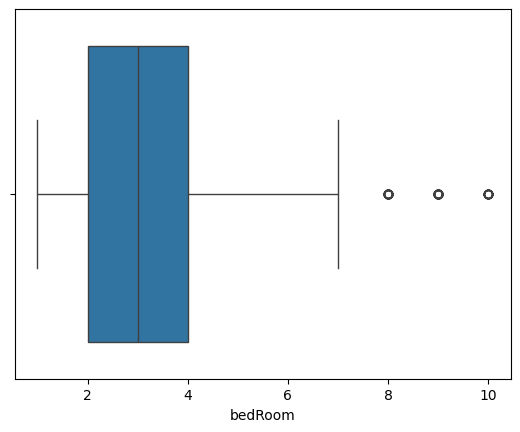

In [331]:
sns.boxplot(x = df['bedRoom'])
plt.show()

In [332]:
df['bedRoom'].describe()

count    3637.000000
mean        3.209238
std         1.399333
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

### Bathroom

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\2878137229.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


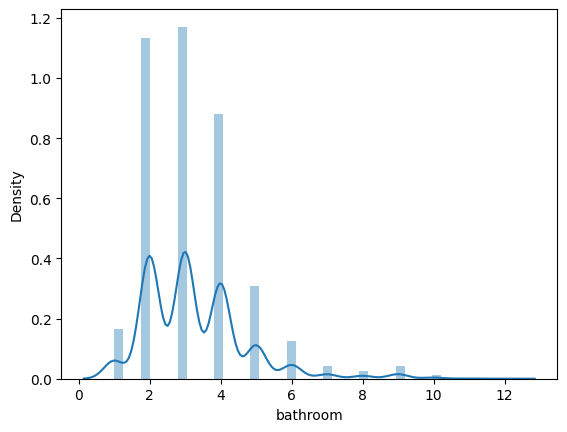

In [333]:
sns.distplot(df['bathroom'])
plt.show()

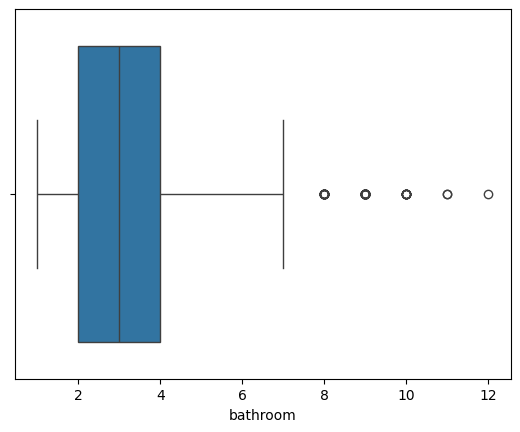

In [334]:
sns.boxplot(x=df['bathroom'])
plt.show()

In [335]:
df[df['bathroom'] > 10].sort_values('bathroom', ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1914,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,0,1,0,0,0,0,146
3064,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,NaN,5000.0,NaN,1,1,0,1,1,0,39
3397,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,NaN,7000.0,NaN,0,0,0,1,0,2,38


### Super Built Up Area

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\1351349074.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


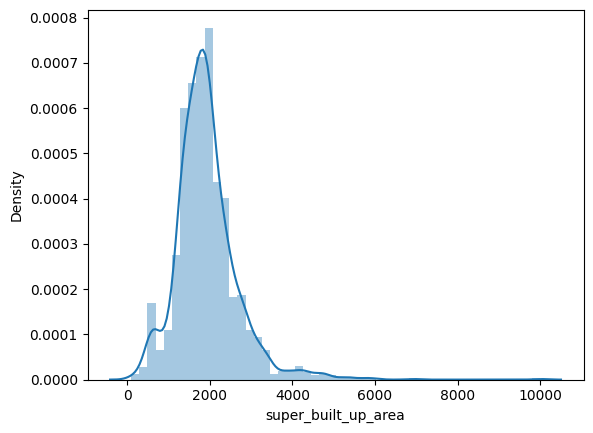

In [336]:
sns.distplot(df['super_built_up_area'])
plt.show()

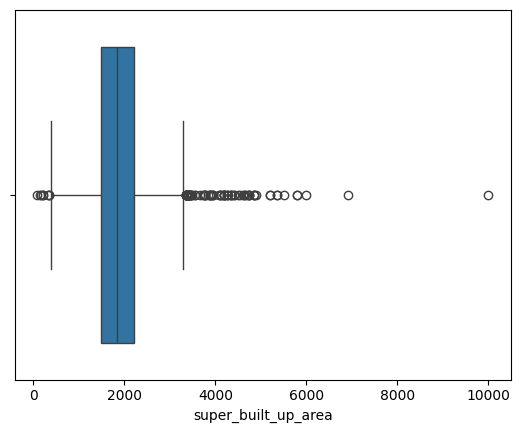

In [337]:
sns.boxplot(x=df['super_built_up_area'])
plt.show()

In [338]:
df['super_built_up_area'].describe()

count     1880.000000
mean      1923.666782
std        763.981194
min         89.000000
25%       1477.250000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [339]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2359,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,0,140
3391,flat,krrish provence estate,sector 2,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,1,1,1,49


### Built Up Area

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\732662566.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


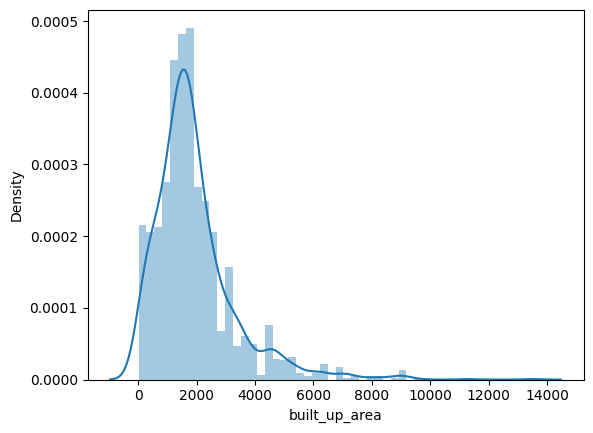

In [340]:
sns.distplot(df['built_up_area'])
plt.show()

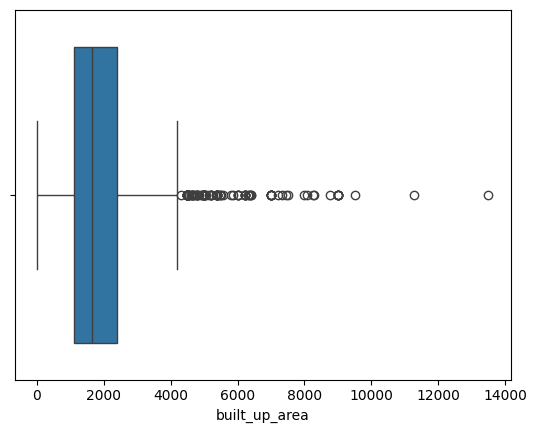

In [341]:
sns.boxplot(x=df['built_up_area'])
plt.show()

In [342]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3162,house,independent,sector 4,0.85,630.0,1500.0,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,Relatively New,NaN,13500.0,NaN,0,0,0,0,1,1,0
3831,house,independent,sector 43,27.50,24366.0,1254.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,0,42


### Carpet Area

In [343]:
df[df['carpet_area'] > 12000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
491,flat,godrej air,sector 85,2.5,1379.0,1812.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Relatively New,NaN,NaN,18122.0,1,0,0,1,1,0,44


In [344]:
df.drop(index=[491], inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\102693169.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


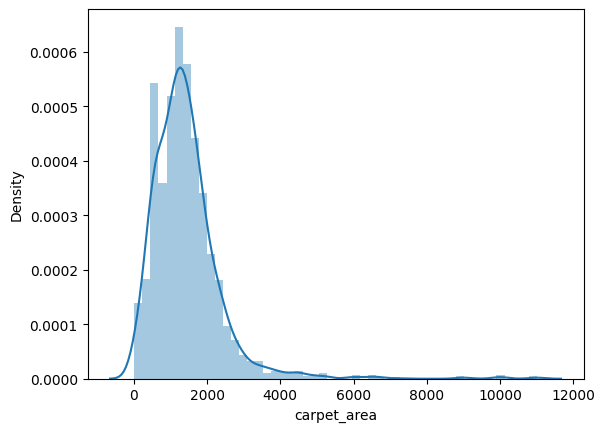

In [345]:
sns.distplot(df['carpet_area'])
plt.show()

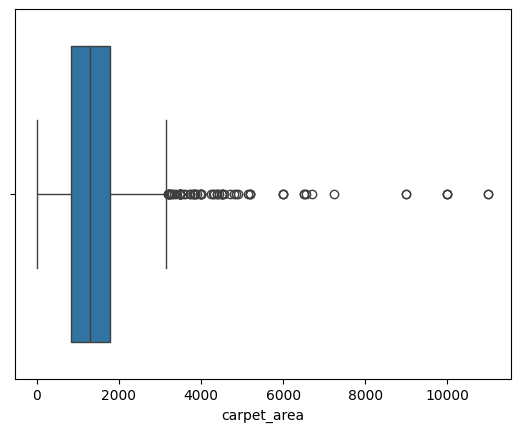

In [346]:
sns.boxplot(x=df['carpet_area'])
plt.show()

In [347]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
336,flat,m3m golfestate,sector 65,13.2,12000.0,1100.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately New,NaN,NaN,11000.0,0,1,0,0,0,1,60
2808,house,independent,sector 26,18.4,1859.0,11000.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.0,0,1,1,1,0,0,60


In [348]:
df.drop(index=[2808], inplace=True)

### Luxury Score

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\1178651402.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


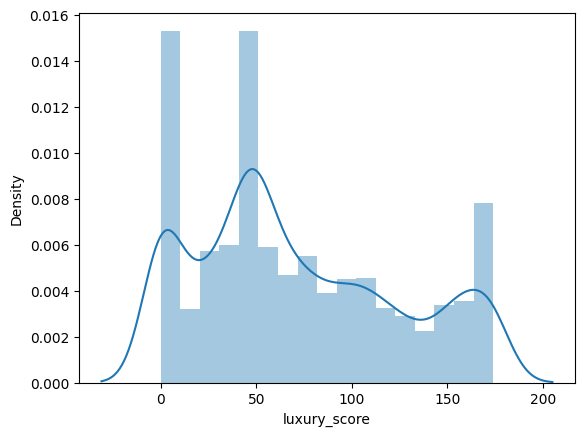

In [349]:
sns.distplot(df['luxury_score'])
plt.show()

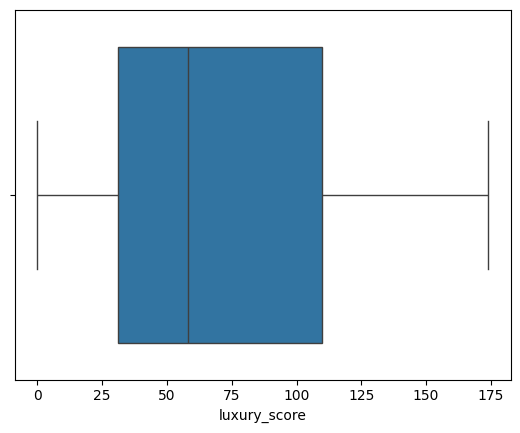

In [350]:
sns.boxplot(x=df['luxury_score'])
plt.show()

### Price_Per_SQFT

In [351]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [352]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,umang winter hills,sector 77,1.00,7502.0,1333.0,Carpet area: 1340 (124.49 sq.m.),2,2,2,3.0,NaN,New Property,NaN,NaN,1340.0,0,0,0,0,0,1,74
1,flat,emaar mgf emerald estate,sector 65,1.75,12545.0,1395.0,Super Built up area 1395(129.6 sq.m.)Carpet ar...,3,3,3,10.0,North-East,Relatively New,1395.0,NaN,809.0,0,1,0,0,0,0,124
2,house,suncity township,sector 54,2.00,3440.0,5814.0,Plot area 60Built Up area: 60 sq.m.Carpet area...,9,9,3,11.0,North,Relatively New,NaN,60.0,59.0,0,1,0,0,0,2,7
3,house,independent,sector 108,1.70,5667.0,3000.0,Built Up area: 3000 (278.71 sq.m.)Carpet area:...,4,4,3+,1.0,North-East,Undefined,NaN,3000.0,2600.0,0,0,0,0,0,1,0
4,flat,dlf the ultima,sector 81,2.30,10994.0,2092.0,Super Built up area 2092(194.35 sq.m.),3,4,3+,6.0,East,New Property,2092.0,NaN,NaN,0,1,0,0,0,2,167


In [353]:
df[df['price_per_sqft'] > 100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
336,flat,m3m golfestate,sector 65,13.2,120000.0,1100.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately New,NaN,NaN,11000.0,0,1,0,0,0,1,60
3831,house,independent,sector 43,27.5,219298.0,1254.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,0,42


In [354]:
df.drop(index=[336, 3831], inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_20740\575062949.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


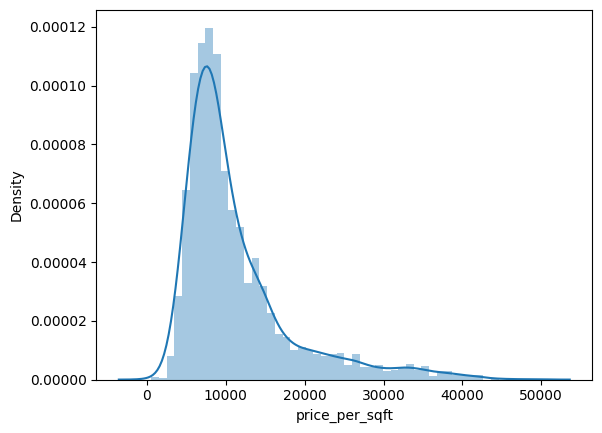

In [355]:
sns.distplot(df['price_per_sqft'])
plt.show()

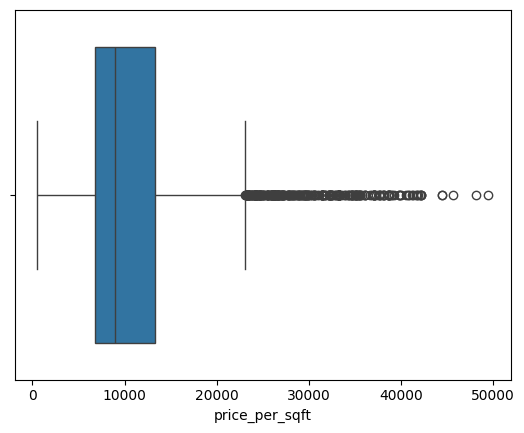

In [356]:
sns.boxplot(x=df['price_per_sqft'])
plt.show()

In [357]:
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
150,house,independent,sector 26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,3.0,East,Moderately New,NaN,4500.0,NaN,1,1,1,1,0,0,103
332,house,independent,sector 28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4,5,3+,4.0,East,Relatively New,NaN,2844.0,NaN,0,1,1,1,0,0,60
414,house,independent,sector 105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,3.0,North,Undefined,NaN,2000.0,1800.0,0,0,0,0,0,1,0
615,house,sushant lok 1 builder floors,sector 43,13.0,48148.0,2700.0,Plot area 300(250.84 sq.m.),3,3,3+,4.0,North,New Property,NaN,2700.0,NaN,0,0,0,1,0,0,7
1026,house,independent,sector 55,5.0,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,NaN,115.0,100.0,0,0,0,0,1,0,44
2116,house,independent,sector 25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6,8,3+,NaN,NaN,Relatively New,NaN,2844.0,NaN,1,1,1,1,0,2,0
2379,house,independent,sector 43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,3+,2.0,North-East,Relatively New,NaN,300.0,250.0,0,1,0,1,0,0,88
3304,house,independent,sector 26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,2,97
3759,house,dlf city plots,sector 26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6,6,3,2.0,East,Relatively New,NaN,4518.0,NaN,1,1,0,0,0,0,121


In [358]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.02)

180.0

In [359]:
df[(df['area']/df['bedRoom'])<180]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
23,house,independent,sector 4,0.92,15257.0,603.0,Plot area 67(56.02 sq.m.),4,4,3,4.0,East,Moderately New,NaN,603.0,NaN,0,0,0,0,1,1,0
56,house,independent,sector 24,4.50,33333.0,1350.0,Plot area 163(136.29 sq.m.)Built Up area: 160 ...,10,8,3+,4.0,East,Relatively New,NaN,160.0,150.0,0,1,1,0,0,0,56
80,house,independent,sector 104,0.71,10143.0,700.0,Plot area 700(65.03 sq.m.),4,2,1,2.0,NaN,New Property,NaN,700.0,NaN,0,0,0,0,0,1,0
111,house,ashok vihar phase iii extension,sector 3,0.40,8889.0,450.0,Plot area 50(41.81 sq.m.),7,4,3+,4.0,NaN,New Property,NaN,450.0,NaN,0,0,0,1,0,1,7
140,house,rajendra park gurgaon,sector 105,0.37,10278.0,360.0,Plot area 360(33.45 sq.m.),4,3,2,3.0,East,Relatively New,NaN,360.0,NaN,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3557,house,independent,sector 7,0.89,18658.0,477.0,Plot area 477(44.31 sq.m.),5,3,2,2.0,East,Old Property,NaN,477.0,NaN,0,0,0,0,0,1,8
3603,house,ansal,sector 43,1.85,34259.0,540.0,Plot area 60(5.57 sq.m.),8,8,3+,5.0,North-West,Relatively New,NaN,60.0,NaN,0,0,0,0,0,1,53
3629,house,independent,sector 7,0.27,12000.0,225.0,Plot area 225(20.9 sq.m.),2,2,1,2.0,North-East,Moderately New,NaN,225.0,NaN,0,0,0,0,0,1,12
3662,house,independent,sector 2,1.00,8230.0,1215.0,Plot area 135(112.88 sq.m.),9,7,3+,3.0,North,Moderately New,NaN,1215.0,NaN,0,0,0,1,0,1,0


In [360]:
df.to_csv(r'C:\Users\ACER\Desktop\Projects\Machine Learning Based Real Estate System\Dataset\Cleaned_Properties_V3.csv', index=False)